# File Creater for the TOLIMAN Pupil

Install necessary packages

In [11]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import jax.numpy as np

import dLux as dl
import dLux.utils as dlu
import dLuxToliman as dlT
import src.OpticsSupport as OpticsSupport
import src.PlottingSupport as PlottingSupport
import zodiax as zdx
from jax import vmap

# plt.style.use(["science", "bright", "no-latex"])

cividis = mpl.colormaps["cividis"]
viridis = mpl.colormaps["viridis"]
coolwarm = mpl.colormaps["coolwarm"]

cividis.set_bad("k", 1.0)
viridis.set_bad("k", 1.0)

mpl.colors.Normalize(vmin=-1, vmax=1)


In [12]:
psf_flag = True
create_cutout = False
make_stl = False

## Parameters

In [13]:
# Aperture parameters
ratio = 1  # Ratio to scale the aperture by (e.g. 5 => 5-inch aperture becomes 1-inch aperture)
aperture_npix = 2000  # Number of pixels across the aperture
aperture_diameter = 0.125 / ratio  # Clear aperture diameter (m)
secondary_diameter = 0.1 / ratio  # Secondary mirror diameter (m)
spider_width = 0.002 / ratio  # Spider width (m)

# Observations wavelegths (bandpass of 530-640nm)
wavelengths = np.linspace(530e-9, 640e-9, 3)  # Wavelengths to simulate (m)

# Substrate parameters
n1 = 1  # Refractive index of free space
# n2 = 1.5424  # Refractive index of Zerodur
n2 = 1.4828 # Refractive index of ULE @589nm

# Mask
mask_path = "diffractive_pupil.npy"
phase_mask = np.load(mask_path) * np.pi  # Load the mask and convert to phase
original_mask = np.copy(phase_mask)  # Save the original mask for later

# Grating parameters
amplitude = 0 #421e-9 #300e-9 # 375e-9  # Amplitude of the grating (m). Peak to peak amplitude of the grating etched in the glass
det_npixels = 1500 #4512 #3648  # DO NOT TOUCH
pixel_scale = dlu.arcsec2rad(0.4219)*ratio # dlu.arcsec2rad(0.375) * ratio  # 0.375 arcsec per pixel
#max_reach = 0.49035 #0.1465*np.sqrt(2) #0.406  # Max wavelength to diffract to 69.1443% of the diagonal length of the detector
period = (1/1.78)*1e-3

## Create the mask

In [14]:
# Make the mask
mask, raw_mask, X, Y = OpticsSupport.HelperFunctions.make_grating_mask(
    phase_mask,
    aperture_npix,
    aperture_diameter,
    secondary_diameter,
    spider_width,
    wavelengths,
    amplitude,
    det_npixels,
    pixel_scale,
    n1,
    n2,
    period,
    out=0.0,
    apply_spiders=False,
    return_raw=True,
)

Grating amplitude (nm): 0.0nm
Grating amplitude (rads): 0.0pi rads
Grating period: 0.0005617977528089888m


Plot mask to check correct pattern and resolution

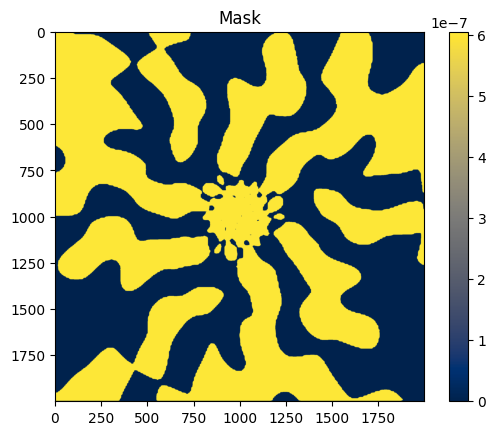

In [15]:
PlottingSupport.Plotting.printColormap(
    mask, title="Mask", colorbar=True, colormap="cividis"
)


Create the phase mask and the instrument

In [16]:
wf_npixels = aperture_npix  # Number of pixels across the wavefront
peak_wavelength = np.mean(wavelengths)  # Peak wavelength of the bandpass (m)
# Create Telescope
phase_mask = OpticsSupport.HelperFunctions.createPhaseMask(
    raw_mask, peak_wavelength, n1, n2
)  # Create the phase mask
# phase_mask = np.load("5k_full_phase_pupil.npy")
mask = dl.Optic(phase=phase_mask)
optics = dlT.TolimanOpticalSystem(
    wf_npixels=wf_npixels, mask=mask, psf_npixels=det_npixels, oversample=1,m1_diameter=aperture_diameter, m2_diameter=secondary_diameter)
# source = dl.PointSource(wavelengths, position=(0, 0))
source = dlT.AlphaCen(n_wavels=3, separation=8, position_angle=-90)
instrument = OpticsSupport.HelperFunctions.createTolimanTelescope(
    optics, source, ratio
)

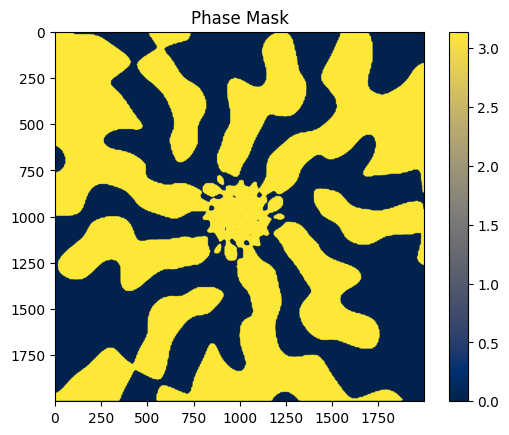

In [17]:
PlottingSupport.Plotting.printColormap(
    phase_mask, title="Phase Mask", colorbar=True, colormap=cividis
)

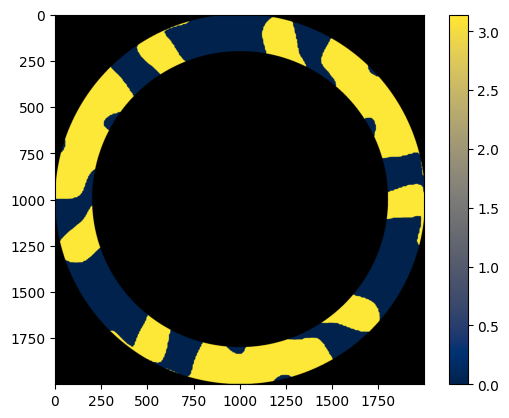

In [18]:
circular_mask_outer = OpticsSupport.HelperFunctions.createCircularMask(
    aperture_npix, aperture_npix, radius=aperture_npix / 2
)
inner_r = (aperture_npix * (secondary_diameter / aperture_diameter)) / 2
circular_mask_inner = 1 - OpticsSupport.HelperFunctions.createCircularMask(
    aperture_npix, aperture_npix, radius=inner_r
)
circular_mask = circular_mask_outer & circular_mask_inner
circular_mask = np.logical_and(circular_mask, np.ones_like(circular_mask))
circular_mask = np.where(circular_mask == 1, phase_mask, np.nan)

plt.imshow(circular_mask, cmap=cividis)# vmin=0, vmax=np.max(phase_mask))
plt.colorbar()
plt.show()

Simulate the PSF

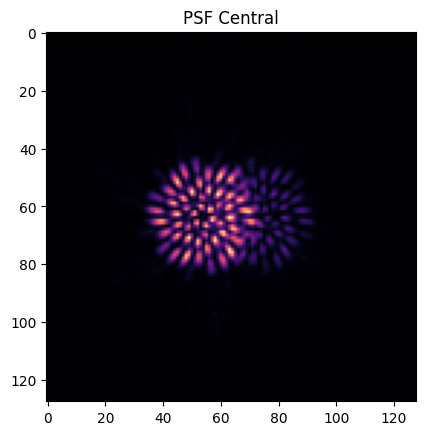

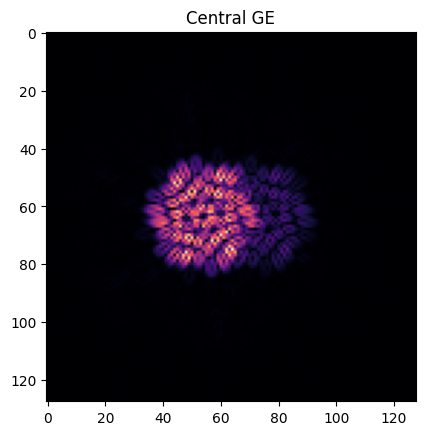

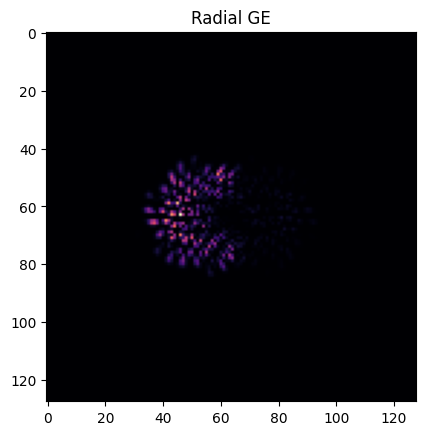

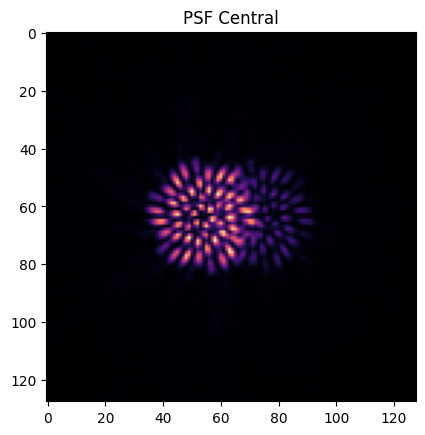

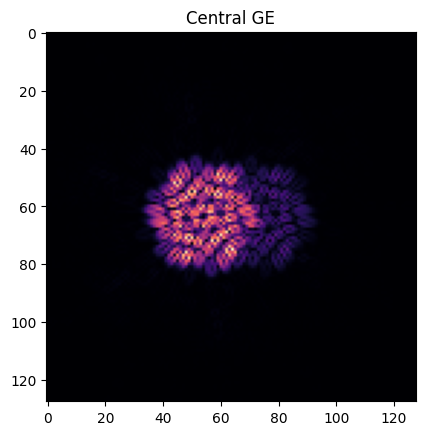

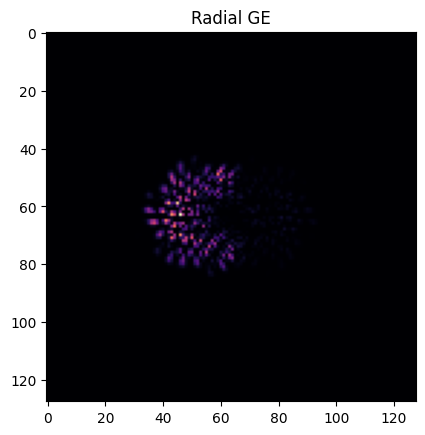

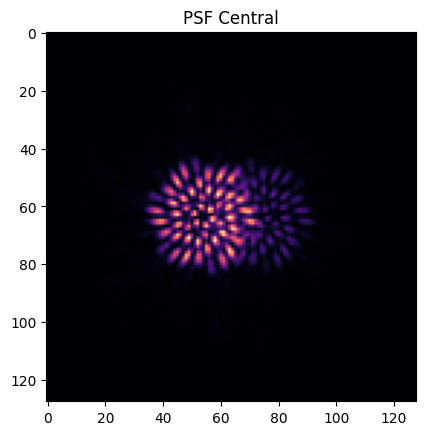

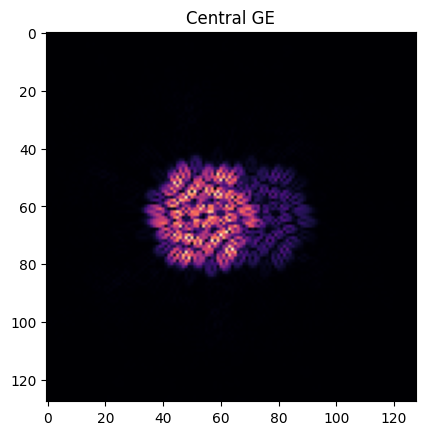

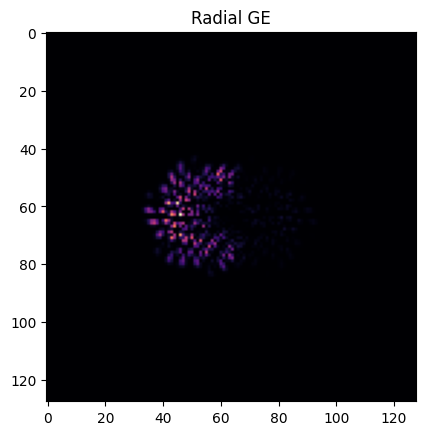

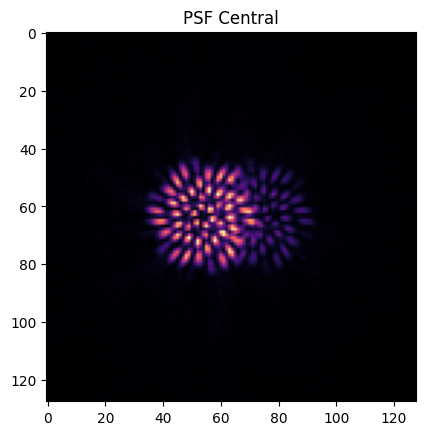

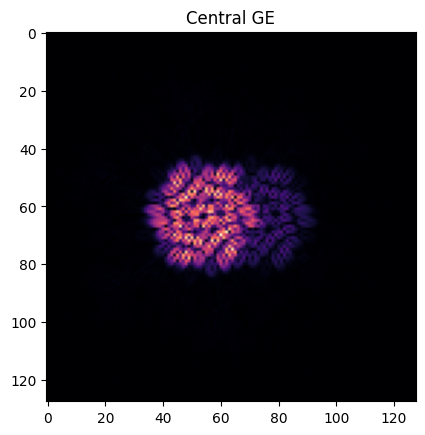

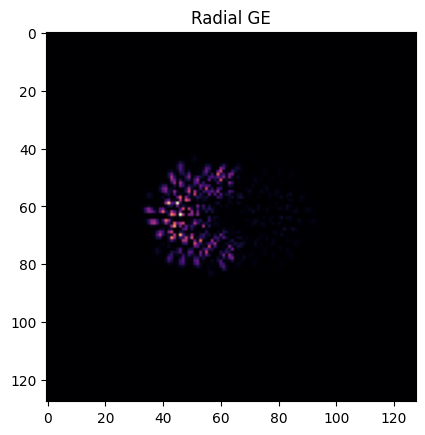

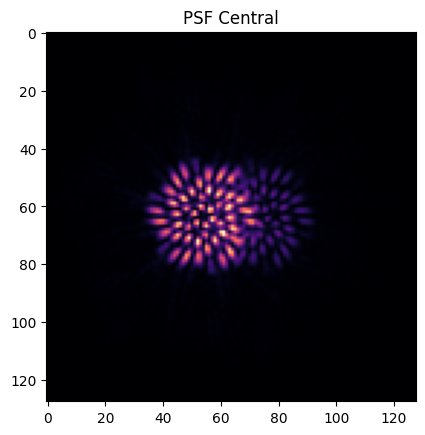

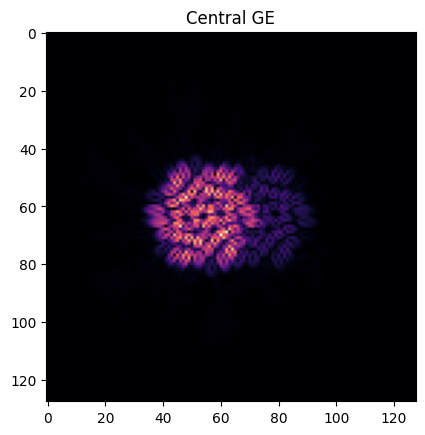

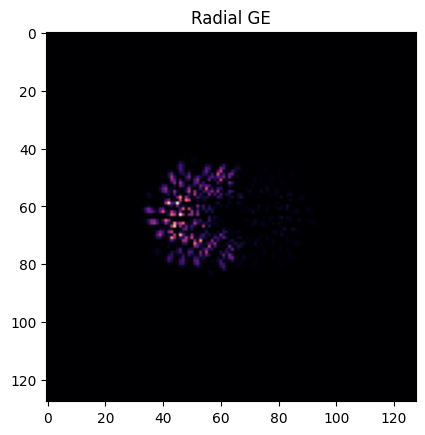

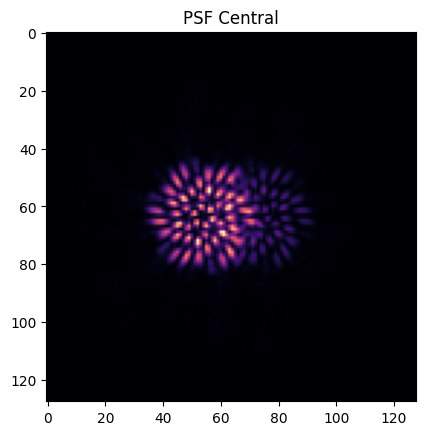

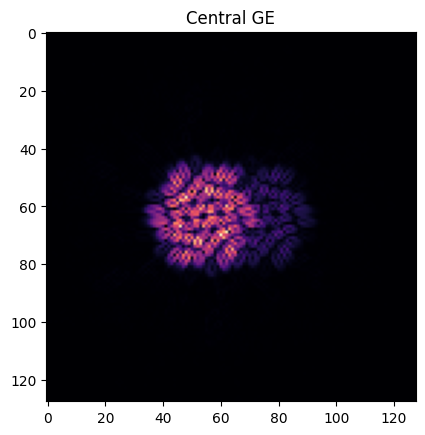

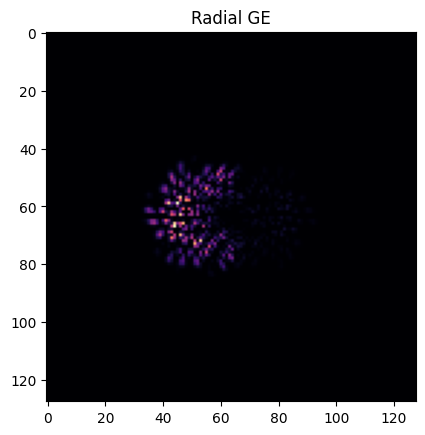

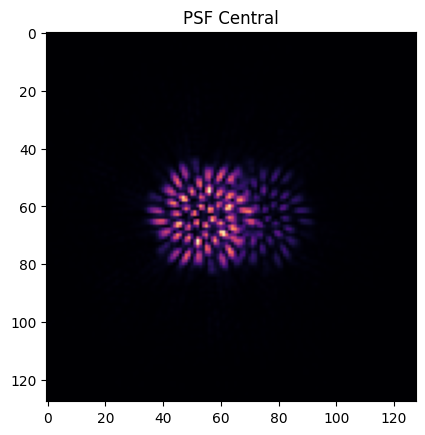

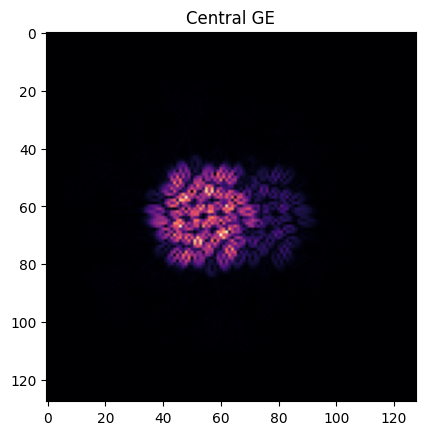

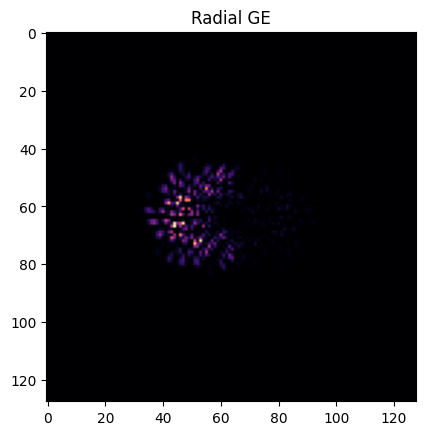

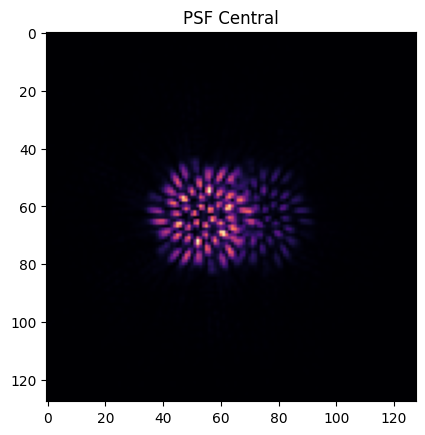

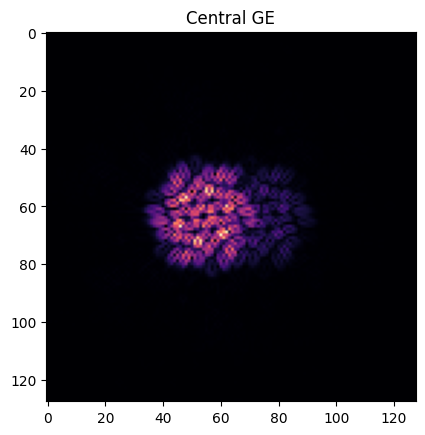

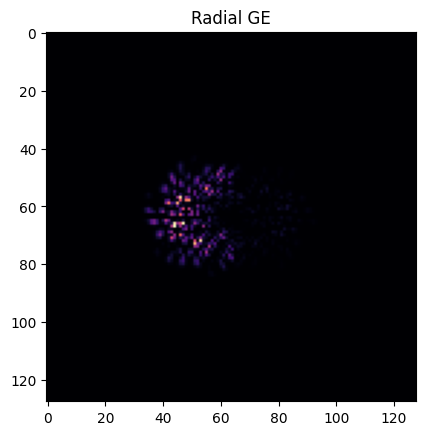

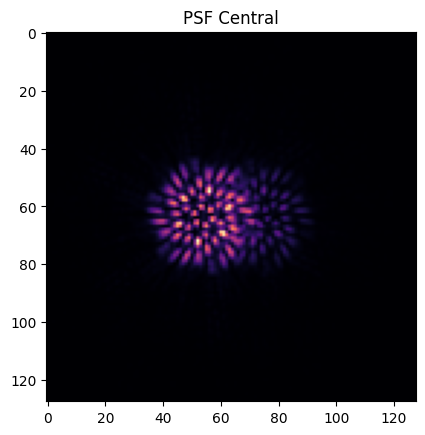

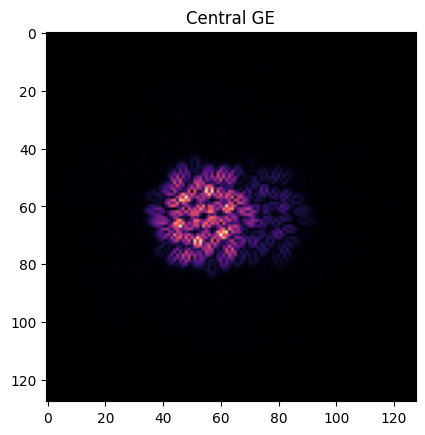

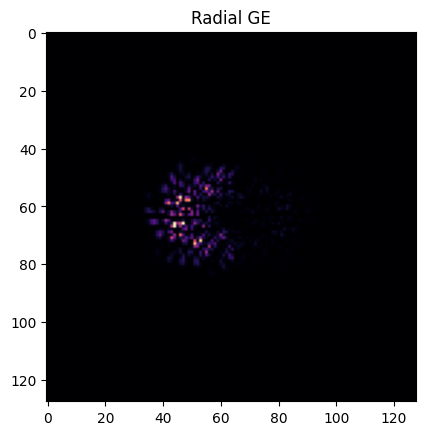

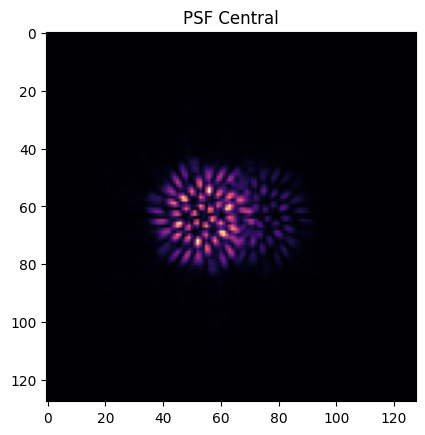

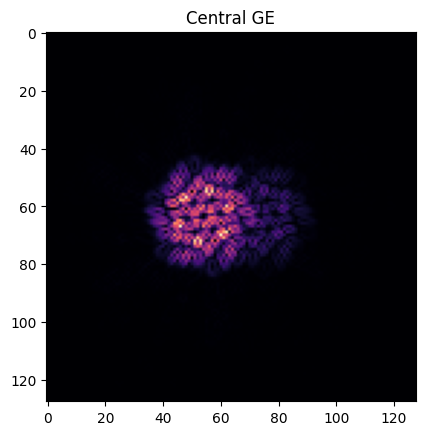

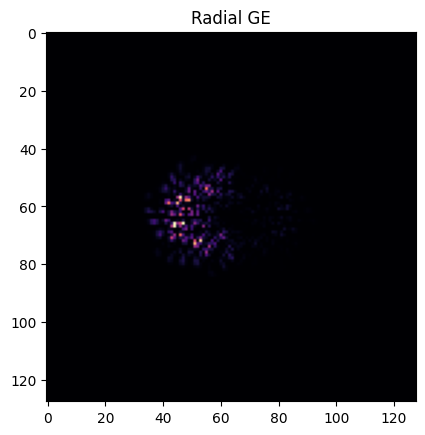

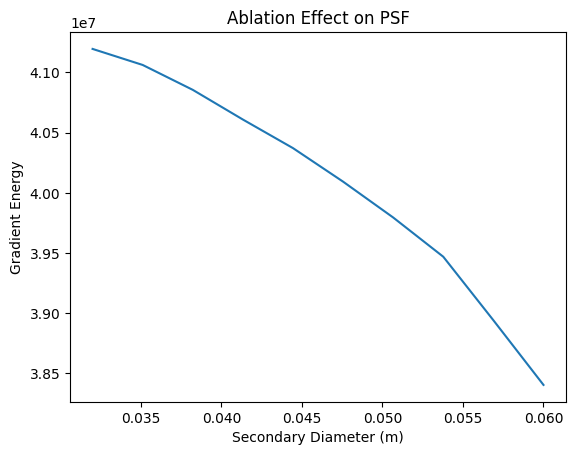

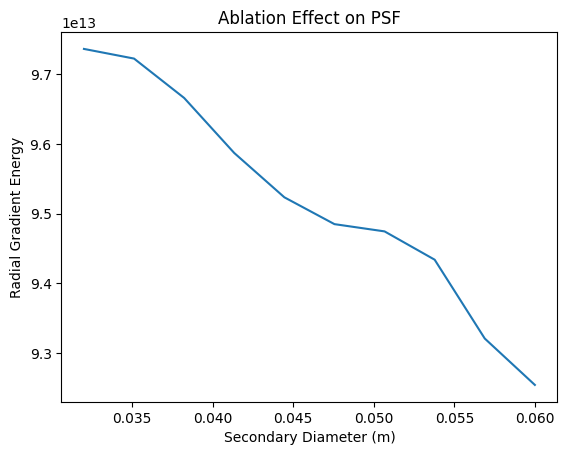

In [19]:
secondary_diameters = np.linspace(0.032, 0.06, 10)
ge = np.zeros(len(secondary_diameters))
rge = np.zeros(len(secondary_diameters))
for i in range(len(secondary_diameters)):
    optics = dlT.TolimanOpticalSystem(
    wf_npixels=wf_npixels, mask=mask, psf_npixels=det_npixels, oversample=1,m1_diameter=aperture_diameter, m2_diameter=secondary_diameters[i])
    instrument = OpticsSupport.HelperFunctions.createTolimanTelescope(
        optics, source, ratio
    )
    psf = instrument.model()

    r = psf.shape[0]
    c = r // 2
    s = 64*1
    central_psf = psf[c - s : c + s, c - s : c + s]

    PlottingSupport.Plotting.printColormap(
        central_psf, title="PSF Central", colorbar=False, colormap="magma"
    )
    np.save(f"central_psf.npy", central_psf)

    central_ge = np.hypot(*np.gradient(central_psf))
    PlottingSupport.Plotting.printColormap(
        central_ge, title="Central GE", colorbar=False, colormap="magma"
    )
    np.save(f"central_ge.npy", central_ge)

    npix = central_psf.shape[0]
    positions = dlu.pixel_coords(npix, npix)
    grads_vec = np.array(np.gradient(central_psf))[::-1]
    radial_ge = np.sum(positions * grads_vec, axis=0) ** 2
  
    PlottingSupport.Plotting.printColormap(
        radial_ge, title="Radial GE", colorbar=False, colormap="magma"
    )
    np.save(f"radial_ge.npy", radial_ge)

    ge = ge.at[i].set(np.sum(central_ge))
    rge = rge.at[i].set(np.sum(radial_ge))

plt.plot(secondary_diameters, ge)
plt.xlabel("Secondary Diameter (m)")
plt.ylabel("Gradient Energy")
plt.title("Ablation Effect on PSF")
plt.show()

plt.plot(secondary_diameters, rge)
plt.xlabel("Secondary Diameter (m)")
plt.ylabel("Radial Gradient Energy")
plt.title("Ablation Effect on PSF")
plt.show()

Display the PSF

In [20]:
marginal_params = {
    "separation": 10.0,  # arcsec
    "pos_angle": 90.0,  # degrees
    "contrast": 3.37,  # contrast ratio
    "flux": 6.6,  # Approx photons per frame
    "pix_scale": 0.3,  # arcsec per pixel
    "wavel": 0.,  # Mean observational wavelength (nm)
    "aberrations": np.zeros(z_basis.shape[0]),  # initial aberration coefficients
}

def model_fn(params, optics):
    """Models a binary star PSF"""
    # Cast from nice units to calculation units
    sep_rad = dlu.arcsec2rad(params["separation"])
    pos_angle = np.deg2rad(params["pos_angle"])
    flux = 10 ** params["flux"]
    d_wavel = 1e-9 * params["wavel"]

    # Get the true positions and fluxes
    positions = dlu.positions_from_sep(np.zeros(2), sep_rad, pos_angle)
    fluxes = dlu.fluxes_from_contrast(flux, params["contrast"])

    # Update the optics with the relevant parameters
    optics = optics.set(
        ["aperture.coefficients", "psf_pixel_scale"],
        [params["aberrations"], params["pix_scale"]],
    )

    # Propagate the PSF for each source position
    psfs = vmap(lambda pos: optics.propagate(wavelengths + d_wavel, pos))(positions)

    # Combine the PSFs with the fluxes to get the final image
    return np.sum(fluxes[:, None, None] * psfs, axis=0)

def fisher_fn(params, optics, n_frames=1, read_noise=1.):
    """Calculate the Fisher Information Matrix"""
    # Generate the PSF and error for the number of frames
    psf = model_fn(params, optics)
    error = np.sqrt((psf + read_noise**2) / n_frames)

    # Calculate the Fisher information matrix
    fn = lambda params: -zdx.loglike(model_fn(params, optics), psf, error).sum()
    return zdx.hessian(fn, params, checkpoint=False)

# Cramer-Rao Lower Bound (CRLB) convenience function
def calc_crlb(optics, n_frames=1, read_noise=2.5):
    F, unravel_fn = fisher_fn(marginal_params, optics, n_frames, read_noise)
    return unravel_fn(np.diag(np.linalg.inv(F)) ** 0.5)

# Set up the optical systems with each mask
airy_optics = optics.set("pupil.coefficients", np.zeros_like(coeffs))
rand_optics = optics.set("pupil.coefficients", coeffs)
ge_optics = optics.set("pupil.coefficients", final_ge_coeffs)
fisher_optics = optics.set("pupil.coefficients", final_fisher_coeffs)

# Calculate the CRLB for each mask
crlbs = {
    "Airy": calc_crlb(airy_optics),
    "Random": calc_crlb(rand_optics),
    "GE Optimised": calc_crlb(ge_optics),
    "Fisher Optimised": calc_crlb(fisher_optics),
}

NameError: name 'z_basis' is not defined